<a href="https://colab.research.google.com/github/francobarrionuevoenv21/MAIE_devs_pub/blob/main/3_T%C3%A9cnicas_de_B%C3%BAsqueda_Franco.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Técnicas de Búsqueda en IA
## Visualización paso a paso (BFS, DFS, A*)
## Instalación

En Colab, ejecutar una vez:

In [ ]:
!pip install networkx matplotlib

De aquí en adelante se puede ejecutar las veces que haga falta

In [7]:
from collections import deque
import heapq
import networkx as nx
import matplotlib.pyplot as plt
import time

## Grafo de ejemplo


In [ ]:
G = nx.DiGraph()

edges = [
    ('A','B',1), ('A','C',4),
    ('B','D',2), ('B','E',5),
    ('C','F',1),
    ('D','G',1), ('E','G',1), ('F','G',3)
]

for u,v,c in edges:
    G.add_edge(u,v,weight=c)

pos = nx.spring_layout(G, seed=42)

## Función de visualización

### Interpretación de los gráficos

Colores:
- 🔵  Nodo no visitado
- 🔴 Visitado
- 🟠 Frontera
- 🟡 Sucesores
- 🟢 Camino solución


In [ ]:
def draw_graph(G, pos, visited=set(), frontier=set(), nuevos=set(), path=[]):
    plt.figure()
    node_colors = []

    for n in G.nodes():
        if n in path:
            node_colors.append('green')
        elif n in nuevos:
            node_colors.append('yellow')
        elif n in frontier:
            node_colors.append('orange')
        elif n in visited:
            node_colors.append('red')
        else:
            node_colors.append('lightblue')

    nx.draw(G, pos, with_labels=True, node_color=node_colors)
    labels = nx.get_edge_attributes(G,'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
    plt.show()


## BFS — Visualización paso a paso

In [ ]:
def bfs_visual(G, start, goal):
    queue = deque([(start, [start])])
    visited = set()

    while queue:

        print("Iteración", len(visited) + 1)
        print("Visitados:", visited)
        print("Frontera:", queue)
        node, path = queue.popleft()
        print("Nodo actual:", node," con camino",path)

        if node == goal:
            print("¡Encontrado!")
            #draw_graph(G=G, pos=pos, visited=visited, frontier={n for n,_ in queue},nuevos=list(G.neighbors(node)), path=path)
            return path

        if node not in visited:
            visited.add(node)
            for neighbor in G.neighbors(node):
                queue.append((neighbor, path + [neighbor]))

        #draw_graph(G=G, pos=pos, visited=visited, frontier={n for n,_ in queue},nuevos=list(G.neighbors(node)), path=path)
        time.sleep(1)



print("BFS:", bfs_visual(G, 'A', 'G'))

Iteración 1
Visitados: set()
Frontera: deque([('A', ['A'])])
Nodo actual: A  con camino ['A']
Iteración 2
Visitados: {'A'}
Frontera: deque([('B', ['A', 'B']), ('C', ['A', 'C'])])
Nodo actual: B  con camino ['A', 'B']
Iteración 3
Visitados: {'B', 'A'}
Frontera: deque([('C', ['A', 'C']), ('D', ['A', 'B', 'D']), ('E', ['A', 'B', 'E'])])
Nodo actual: C  con camino ['A', 'C']
Iteración 4
Visitados: {'B', 'C', 'A'}
Frontera: deque([('D', ['A', 'B', 'D']), ('E', ['A', 'B', 'E']), ('F', ['A', 'C', 'F'])])
Nodo actual: D  con camino ['A', 'B', 'D']
Iteración 5
Visitados: {'D', 'B', 'C', 'A'}
Frontera: deque([('E', ['A', 'B', 'E']), ('F', ['A', 'C', 'F']), ('G', ['A', 'B', 'D', 'G'])])
Nodo actual: E  con camino ['A', 'B', 'E']
Iteración 6
Visitados: {'A', 'D', 'E', 'C', 'B'}
Frontera: deque([('F', ['A', 'C', 'F']), ('G', ['A', 'B', 'D', 'G']), ('G', ['A', 'B', 'E', 'G'])])
Nodo actual: F  con camino ['A', 'C', 'F']
Iteración 7
Visitados: {'F', 'A', 'D', 'E', 'C', 'B'}
Frontera: deque([('G', ['A

## DFS — Visualización paso a paso

In [ ]:
def dfs_visual(G, start, goal):
    stack = [(start, [start])]
    visited = set()

    while stack:
        print('Pila:', stack)
        node, path = stack.pop()

        print("Iteración", len(visited) + 1)
        print("Visitados:", visited)
        #print("Frontera:", queue)
        #node, path = queue.popleft()
        print("Nodo actual:", node," con camino",path)

        #draw_graph(G, pos, visited, {n for n,_ in stack}, path)
        time.sleep(1)

        if node == goal:
            return path

        if node not in visited:
            visited.add(node)
            for neighbor in G.neighbors(node):
                stack.append((neighbor, path + [neighbor]))

#print("DFS:", dfs_visual(G, 'A', 'G'))


Pila: [('A', ['A'])]
Iteración 1
Visitados: set()
Nodo actual: A  con camino ['A']
Pila: [('B', ['A', 'B']), ('C', ['A', 'C'])]
Iteración 2
Visitados: {'A'}
Nodo actual: C  con camino ['A', 'C']
Pila: [('B', ['A', 'B']), ('F', ['A', 'C', 'F'])]
Iteración 3
Visitados: {'C', 'A'}
Nodo actual: F  con camino ['A', 'C', 'F']
Pila: [('B', ['A', 'B']), ('G', ['A', 'C', 'F', 'G'])]
Iteración 4
Visitados: {'C', 'F', 'A'}
Nodo actual: G  con camino ['A', 'C', 'F', 'G']
DFS: ['A', 'C', 'F', 'G']


## A* — Visualización paso a paso (demo)

In [ ]:
heuristic = {
    'A': 7,'B': 6,'C': 2,'D': 1,'E': 1,'F': 3,'G': 0
}

# %%
def astar_visual(G, start, goal, h):
    pq = [(0, start, [start])]
    g_costs = {start: 0}
    visited = set()

    while pq:

        print('Pila:', heapq)

        f, node, path = heapq.heappop(pq)

        print("Iteración", len(visited) + 1)
        print("Visitados:", visited)
        #print("Frontera:", queue)
        #node, path = queue.popleft()
        print("Nodo actual:", node," con camino",path)

        frontier_nodes = {n for _,n,_ in pq}
        #draw_graph(G, pos, visited, frontier_nodes, path)
        time.sleep(1)

        if node == goal:
            return path, g_costs[node]

        visited.add(node)

        for neighbor in G.neighbors(node):
            cost = G[node][neighbor]['weight']
            g = g_costs[node] + cost

            if neighbor not in g_costs or g < g_costs[neighbor]:
                g_costs[neighbor] = g
                f = g + h[neighbor]
                heapq.heappush(pq, (f, neighbor, path + [neighbor]))

print("A*:", astar_visual(G, 'A', 'G', heuristic))

Pila: <module 'heapq' from '/usr/lib/python3.12/heapq.py'>
Iteración 1
Visitados: set()
Nodo actual: A  con camino ['A']
Pila: <module 'heapq' from '/usr/lib/python3.12/heapq.py'>
Iteración 2
Visitados: {'A'}
Nodo actual: C  con camino ['A', 'C']
Pila: <module 'heapq' from '/usr/lib/python3.12/heapq.py'>
Iteración 3
Visitados: {'C', 'A'}
Nodo actual: B  con camino ['A', 'B']
Pila: <module 'heapq' from '/usr/lib/python3.12/heapq.py'>
Iteración 4
Visitados: {'C', 'B', 'A'}
Nodo actual: D  con camino ['A', 'B', 'D']
Pila: <module 'heapq' from '/usr/lib/python3.12/heapq.py'>
Iteración 5
Visitados: {'C', 'D', 'B', 'A'}
Nodo actual: G  con camino ['A', 'B', 'D', 'G']
A*: (['A', 'B', 'D', 'G'], 4)


## A* — Visualización paso a paso (Ejercicio 7 y 8, guía 4)

In [ ]:
# @title A* implementation


# %%
def astar_visual(G, start, goal, h):
    pq = [(0, start, [start])]
    g_costs = {start: 0}
    visited = set()

    while pq:

        f, node, path = heapq.heappop(pq)

        print("Iteración", len(visited) + 1)
        print("Visitados:", visited)
        print("Nodo actual:", node," con camino",path)

        frontier_nodes = {n for _,n,_ in pq}
        #draw_graph(G, pos, visited, frontier_nodes, path)
        time.sleep(1)

        if node == goal:
            return path, g_costs[node]

        visited.add(node)

        for neighbor in G.neighbors(node):
            cost = G[node][neighbor]['weight']
            g = g_costs[node] + cost

            if neighbor not in g_costs or g < g_costs[neighbor]:
                g_costs[neighbor] = g
                f = g + h[neighbor]
                heapq.heappush(pq, (f, neighbor, path + [neighbor]))

#print("A*:", astar_visual(G, 'A', 'G', heuristic))

### Ejercicio 7

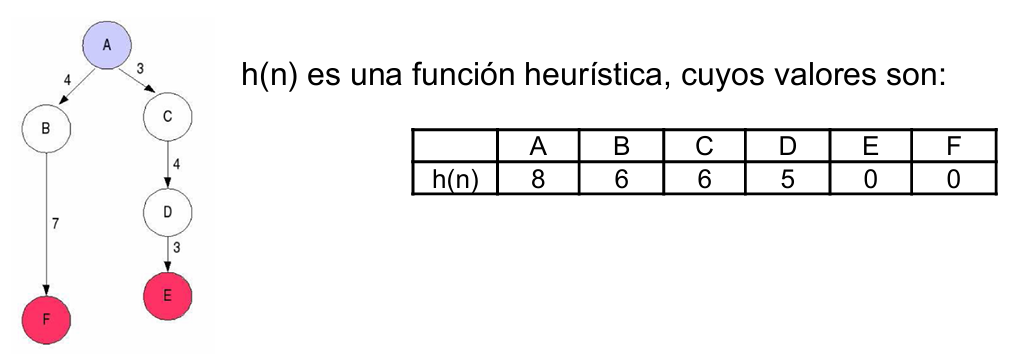

In [ ]:
G = nx.DiGraph()

edges = [
    ('A','B', 4), ('A','C',3),
    ('B', 'F', 7), ('C', 'D', 4),
    ('D', 'E', 3)
]

for u,v,c in edges:
    G.add_edge(u,v,weight=c)

#pos = nx.spring_layout(G, seed=42)

heuristic = {
    'A': 8,'B': 6,'C': 6,'D': 5,'E': 0,'F': 0
}

In [ ]:
print("A*:", astar_visual(G, 'A', 'G', heuristic))

Iteración 1
Visitados: set()
Nodo actual: A  con camino ['A']
Iteración 2
Visitados: {'A'}
Nodo actual: C  con camino ['A', 'C']
Iteración 3
Visitados: {'C', 'A'}
Nodo actual: B  con camino ['A', 'B']
Iteración 4
Visitados: {'B', 'C', 'A'}
Nodo actual: F  con camino ['A', 'B', 'F']
Iteración 5
Visitados: {'B', 'C', 'F', 'A'}
Nodo actual: D  con camino ['A', 'C', 'D']
Iteración 6
Visitados: {'D', 'B', 'A', 'F', 'C'}
Nodo actual: E  con camino ['A', 'C', 'D', 'E']
A*: None


### Ejercicio 8


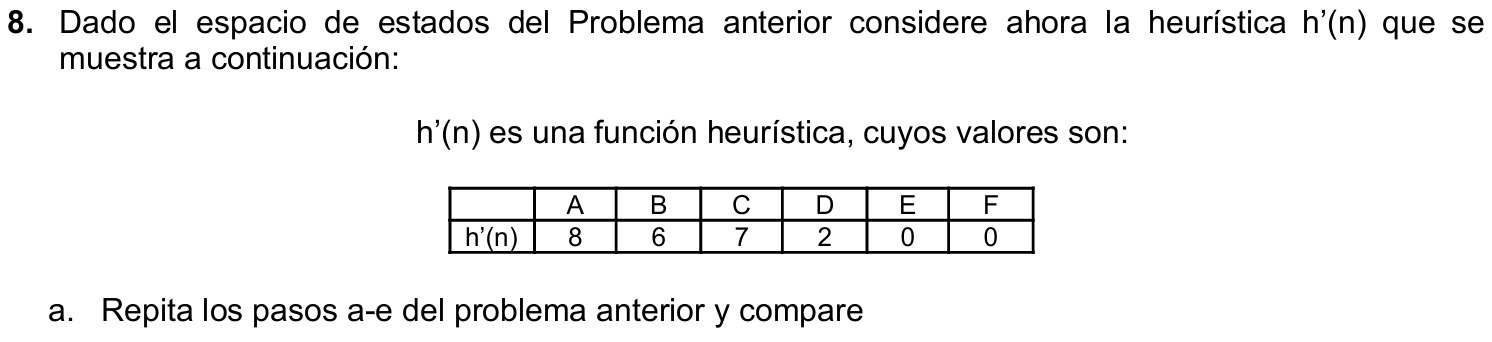

In [ ]:
G = nx.DiGraph()

edges = [
    ('A','B', 4), ('A','C',3),
    ('B', 'F', 7), ('C', 'D', 4),
    ('D', 'E', 3)
]

for u,v,c in edges:
    G.add_edge(u,v,weight=c)

#pos = nx.spring_layout(G, seed=42)

heuristic = {
    'A': 8,'B': 6,'C': 7,'D': 2,'E': 0,'F': 0
}

In [ ]:
print("A*:", astar_visual(G, 'A', 'G', heuristic))

Iteración 1
Visitados: set()
Nodo actual: A  con camino ['A']
Iteración 2
Visitados: {'A'}
Nodo actual: B  con camino ['A', 'B']
Iteración 3
Visitados: {'B', 'A'}
Nodo actual: C  con camino ['A', 'C']
Iteración 4
Visitados: {'B', 'C', 'A'}
Nodo actual: D  con camino ['A', 'C', 'D']
Iteración 5
Visitados: {'B', 'C', 'A', 'D'}
Nodo actual: E  con camino ['A', 'C', 'D', 'E']
Iteración 6
Visitados: {'B', 'C', 'A', 'D', 'E'}
Nodo actual: F  con camino ['A', 'B', 'F']
A*: None


### Ejercicio 9

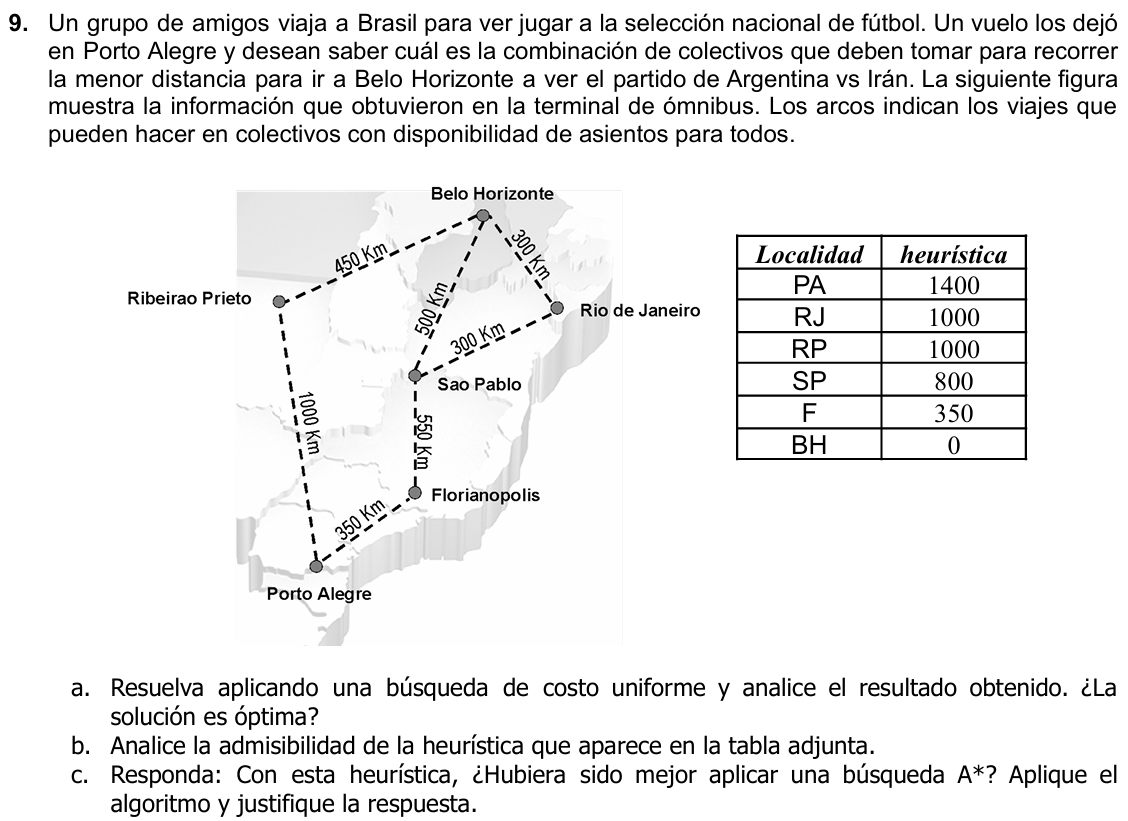

In [10]:
# @title UCS implementation from A*

# I modified the heuristic for A* in order to obtain the path cost instead
def ucs_visual(G, start, goal):
    pq = [(0, start, [start])]  # (cost, node, path)
    g_costs = {start: 0}
    visited = set()

    while pq:

        g, node, path = heapq.heappop(pq)

        print("Iteración", len(visited) + 1)
        print("Visitados:", visited)
        print("Nodo actual:", node, "con camino", path)

        frontier_nodes = {n for _, n, _ in pq}
        # draw_graph(G, pos, visited, frontier_nodes, path)
        time.sleep(1)

        if node == goal:
            return path, g_costs[node]

        if node in visited:
            continue

        visited.add(node)

        for neighbor in G.neighbors(node):
            cost = G[node][neighbor]['weight']
            new_g = g_costs[node] + cost

            if neighbor not in g_costs or new_g < g_costs[neighbor]:
                g_costs[neighbor] = new_g
                heapq.heappush(pq, (new_g, neighbor, path + [neighbor])) # priority now is given by g(n)

In [19]:
# UCS IMPLEMENTATION

G = nx.DiGraph()

# PA: Porto Alegre; RJ: Río de Janeiro; RP: Ribeirao Preto; SP: Sao Pablo; F: Florianópolis; BH: Belo Horizonte

edges = [
    ('PA', 'RP', 1000), ('PA', 'F', 350), # n: PA
    ('RP', 'BH', 450), # n: RP
    ('F', 'SP', 550), # n: SP
    ('SP', 'BH', 500), ('SP', 'RJ', 300), # n: SP
    ('RJ', 'BH', 300) # n: RJ
]

for u,v,c in edges:
    G.add_edge(u,v,weight=c)

pos = nx.spring_layout(G, seed=42)

# Set start and goal nodes
start = 'PA'
goal = 'BH'

# Run the searching
ucs_visual(G, start, goal)

Iteración 1
Visitados: set()
Nodo actual: PA con camino ['PA']
Iteración 2
Visitados: {'PA'}
Nodo actual: F con camino ['PA', 'F']
Iteración 3
Visitados: {'F', 'PA'}
Nodo actual: SP con camino ['PA', 'F', 'SP']
Iteración 4
Visitados: {'F', 'PA', 'SP'}
Nodo actual: RP con camino ['PA', 'RP']
Iteración 5
Visitados: {'F', 'PA', 'RP', 'SP'}
Nodo actual: RJ con camino ['PA', 'F', 'SP', 'RJ']
Iteración 6
Visitados: {'RJ', 'F', 'RP', 'PA', 'SP'}
Nodo actual: BH con camino ['PA', 'F', 'SP', 'BH']


(['PA', 'F', 'SP', 'BH'], 1400)

In [18]:
# A* IMPLEMENTATION

G = nx.DiGraph()

# PA: Porto Alegre; RJ: Río de Janeiro; RP: Ribeirao Preto; SP: Sao Pablo; F: Florianópolis; BH: Belo Horizonte

edges = [
    ('PA', 'RP', 1000), ('PA', 'F', 350), # n: PA
    ('RP', 'BH', 450), # n: RP
    ('F', 'SP', 550), # n: SP
    ('SP', 'BH', 500), ('SP', 'RJ', 300), # n: SP
    ('RJ', 'BH', 300) # n: RJ
]

for u,v,c in edges:
    G.add_edge(u,v,weight=c)

#pos = nx.spring_layout(G, seed=42)

heuristic = {
    'PA': 1400, 'RJ': 1000, 'RP': 1000, 'SP': 800, 'F': 350, 'BH': 0
}

# Set start and goal nodes
start = 'PA'
goal = 'BH'

print("A*:", astar_visual(G, start, goal, heuristic))

Iteración 1
Visitados: set()
Nodo actual: PA  con camino ['PA']
Iteración 2
Visitados: {'PA'}
Nodo actual: F  con camino ['PA', 'F']
Iteración 3
Visitados: {'F', 'PA'}
Nodo actual: SP  con camino ['PA', 'F', 'SP']
Iteración 4
Visitados: {'F', 'PA', 'SP'}
Nodo actual: BH  con camino ['PA', 'F', 'SP', 'BH']
A*: (['PA', 'F', 'SP', 'BH'], 1400)



Esto permite ver:
- Cómo BFS expande en capas
- Cómo DFS se profundiza
- Cómo A* prioriza nodos prometedores

---

## Ejercicios

1. Cambiar layout del grafo
1. Hacer que se muestren como las listas de frontera, visitados y sucesores por iteración como en el algoritmo BFS
2. Computar los nodos expandidos
3. Implemetar UCS y comparar
4. Implemetar Greedy Search y comparar
5. Probar heurísticas malas